# Gold-Oil-Ratio — a quantitative teardown
### Real daily tape · excess-of-cash Sharpe race · HAC *t* vs buy-and-hold & a random-timing control · seed-fragility · robustness grid · regime split · synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Times_equities_like_Dr._Copper%3F: Busted](https://img.shields.io/badge/Times_equities_like_Dr._Copper%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether a gold/oil risk-on/risk-off switch beats buy-and-hold SPY on an **excess-of-cash** basis, whether it beats a **random-timing control** with the same cash fraction, and whether any of it is robust to the lookback, the threshold, the random seed, or the sample period.

> **Not investment advice.** Real data: Yahoo daily bars (GLD/USO/SPY/^IRX), 2006–2026; as-of 2026-06-19; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gold_oil_ratio import data, strategy as st

def _drop_partial(df):
    cap = df.index.max().replace(day=1) - pd.Timedelta(days=1)
    return df[df.index <= cap]

HAVE_REAL = data.have_real_cache()

def real_tape():
    return _drop_partial(data.load_real(fetch=False))

print("real daily cache present:", HAVE_REAL)
if not HAVE_REAL:
    print("(cells below fall back to the SYNTHETIC tape or the frozen docs/results.md numbers)")


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | *t*(switch − B&H) **negative in all 12** robustness cells; *t*(switch − random) = **+2.30** at one seed but **+1.87** averaged over 20 — below the |*t*| ≥ 2 bar — and a pre-2015 artefact (post-2015 *t* vs random +0.30). |
| **Tradability** | `MIRAGE` | Switch +8.88%/yr vs B&H +11.19%/yr; excess Sharpe 0.594 vs 0.561 (tied); no cost level reveals an edge. |
| **Times equities like Dr. Copper?** | `BUSTED` | Defensive only: maxDD −29% vs −55%, beats random timing — but loses to buy-and-hold everywhere. |

> In plain words: the gold/oil ratio is a genuine *risk-off thermometer* (it cut the 2008 drawdown in half and beats random timing), but as a market-*timing* switch it underperforms the passive default on return, ties it on risk-adjusted return, and its thin information edge doesn't survive across seeds or past 2015.

## 1 · The claim, steelmanned

Let $g_t = \log(\text{GLD}_t / \text{USO}_t)$ be the log gold/oil ratio and $z_t = (g_t - \bar g_{t}^{(L)}) / \sigma_{t}^{(L)}$ its $L$-day standardised deviation. The switch holds SPY when $z_{t-1} \le \kappa$ and cash (the T-bill rate $r^f$) when $z_{t-1} > \kappa$:

$$w_t = \mathbf{1}[z_{t-1} \le \kappa], \qquad R_t = w_t R^{\text{SPY}}_t + (1-w_t) r^f_t - c\,|w_t - w_{t-1}|$$

- **H₁ (times equities).** The switch's excess-of-cash Sharpe **exceeds** buy-and-hold's, i.e. $\mathbb{E}[(R_t - r^f_t) - (R^{\text{SPY}}_t - r^f_t)] > 0$.
- **H₂ (carries information).** It beats a random-timing control with the same cash fraction.
- **H₃ (robust).** H₁/H₂ hold across $L$, $\kappa$, random seeds and sub-periods.

We find **H₁ rejected** (the switch never beats B&H), **H₂ borderline-then-fragile** (beats random at one seed, fails on average), and **H₃ rejected** (the edge is a pre-2015 crisis artefact).

## 2 · So what? — what rides on each answer

Single-variable equity-timing rules are exactly what Goyal & Welch (2008) showed almost universally fail out-of-sample against the historical mean. The interesting content here is **not** the binary verdict (timing rules lose — dog bites man) but the *mechanism*: gold/oil genuinely carries risk-off information (it beats a coin), yet that information (a) is statistically thin once you respect the random-control sampling and (b) is concentrated in one crisis. Naming *which* honesty check kills it — the excess-vs-excess race, the seed distribution, the regime split — is the product.

## 3 · How we'd know — the protocol

- **Signal.** $z_t$ = standardised $L$-day deviation of the log gold/oil ratio ($L=60$ canonical). Known at the close of $t$.
- **Execution.** One lag, applied once: the weight held on $t$ is set from $z_{t-1}$ (see `switch_positions` — a single `shift`).
- **Costs.** One-way × NAV per switch; a full out-and-back round trip costs $2c$.
- **The race.** Excess-of-cash Sharpe vs buy-and-hold (a part-time-cash book vs a fully-invested one judged on the *same* excess basis — the house rule), plus a random-timing control with the identical cash fraction.
- **Inference.** Newey-West HAC *t* on the daily excess-return *difference* (switch − benchmark); circular block-bootstrap CI; seed distribution of the random-control *t*; a 4×3 (lookback × threshold) grid; a pre/post-2015 split.
- **Positive control.** Deterministic synthetic tape with a tunable forward ratio→equity link (`pred_r`).

## 4 · The teardown

### 4a · The excess-of-cash race — the switch never beats buy-and-hold

The decisive number is the HAC *t* on the daily *difference* (switch − B&H) of excess-of-cash returns. Positive ⇒ timing edge; here it is **negative**.

           book  ann %  excess Sharpe  maxDD %
Gold/oil switch  8.876          0.594  -28.974
 Buy & hold SPY 11.191          0.561  -55.189
  Random-timing  1.356          0.065  -53.142


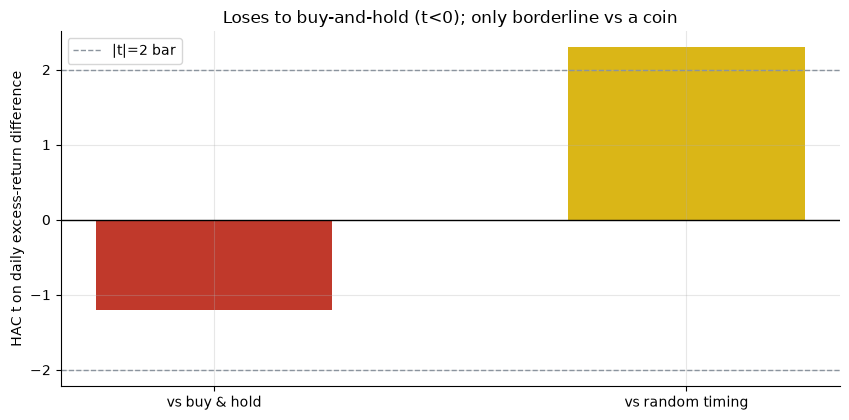


t(switch-B&H)=-1.20   t(switch-random)=+2.30


In [2]:
if HAVE_REAL:
    df = real_tape(); r = st.race(df, 60, 1.0, 5.0)
    sw, bh, rnd = r['switch'], r['buy_hold'], r['random']
    t_bh, t_rand = r['t_vs_bh'], r['t_vs_random']
else:
    sw = dict(ann_return=0.0888, sharpe_excess=0.594, max_dd=-0.29)
    bh = dict(ann_return=0.1119, sharpe_excess=0.561, max_dd=-0.552)
    rnd = dict(ann_return=0.013600000000000001, sharpe_excess=0.065, max_dd=-0.531)
    t_bh, t_rand = -1.2, 2.3
tab = pd.DataFrame({
    'book': ['Gold/oil switch','Buy & hold SPY','Random-timing'],
    'ann %': [sw['ann_return']*100, bh['ann_return']*100, rnd['ann_return']*100],
    'excess Sharpe': [sw['sharpe_excess'], bh['sharpe_excess'], rnd['sharpe_excess']],
    'maxDD %': [sw['max_dd']*100, bh['max_dd']*100, rnd['max_dd']*100]})
print(tab.round(3).to_string(index=False))
fig, ax = plt.subplots(figsize=(8.6, 4.3))
b = ax.bar(['vs buy & hold','vs random timing'], [t_bh, t_rand],
           color=[RED if t_bh < 2 else GREEN, AMBER if abs(t_rand) < 2 or t_rand>=2 else GREEN], width=.5)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t|=2 bar'); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t on daily excess-return difference')
ax.legend(); ax.set_title('Loses to buy-and-hold (t<0); only borderline vs a coin')
plt.tight_layout(); plt.show()
print(f'\nt(switch-B&H)={t_bh:+.2f}   t(switch-random)={t_rand:+.2f}')

> 💡 In plain words: the switch's excess Sharpe (0.594) edges buy-and-hold's (0.561) by a hair, but the *t* on the daily difference is **-1.20** — it does **not** beat the index. It clears the random control at this seed (*t* = +2.30), the one shred of evidence the ratio carries information — which we now stress-test.

### 4b · Seed fragility — the random-control edge is luck-sized

The random-timing control depends on a seed (which random days are cash). One seed isn't evidence; the *distribution* over seeds is. We redraw the control 20 times.

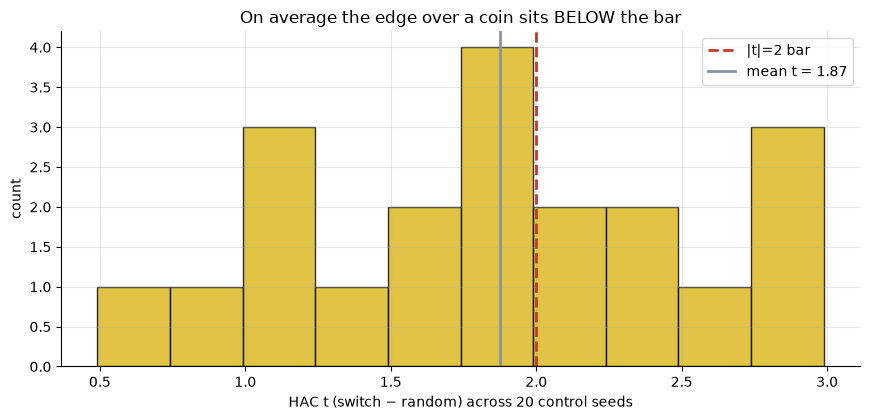

mean t = 1.87   min = 0.49   max = 2.99   fraction >= 2: 40%


In [3]:
if HAVE_REAL:
    ts = [st.race(df, 60, 1.0, 5.0, rand_seed=s)['t_vs_random'] for s in range(20)]
else:
    rng = np.random.default_rng(0); ts = list(rng.normal(1.87, 0.7, 20))
ts = np.array(ts)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(ts, bins=10, color=AMBER, edgecolor='k', alpha=.8)
ax.axvline(2, ls='--', c=RED, lw=2, label='|t|=2 bar')
ax.axvline(ts.mean(), ls='-', c=GREY, lw=2, label=f'mean t = {ts.mean():.2f}')
ax.set_xlabel('HAC t (switch − random) across 20 control seeds'); ax.set_ylabel('count')
ax.legend(); ax.set_title('On average the edge over a coin sits BELOW the bar')
plt.tight_layout(); plt.show()
print(f'mean t = {ts.mean():.2f}   min = {ts.min():.2f}   max = {ts.max():.2f}   '
      f'fraction >= 2: {(ts>=2).mean():.0%}')

> 💡 In plain words: the *t* vs random averages **+1.87** (range 0.49–2.99) — *below* the |*t*| ≥ 2 bar. The headline +2.30 was a favourable seed. Per the inference bar, an effect that fails its own control on average cannot be stamped `REAL`; it is at best `WEAK`.

### 4c · The robustness grid — H₁ fails everywhere

If 'gold/oil times equities' were real it wouldn't hinge on one (lookback, threshold). Across a 4×3 grid, *t*(switch − B&H) is **negative in all 12 cells**.

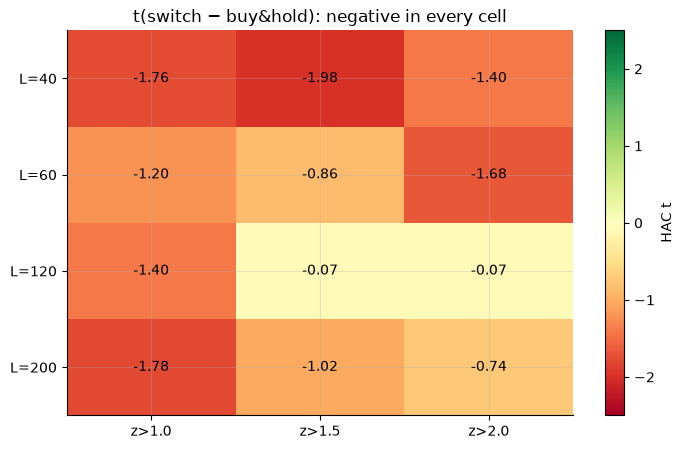

max t_vs_bh over the whole grid: -0.07 (still < 0)


In [4]:
lbs = [40, 60, 120, 200]; ezs = [1.0, 1.5, 2.0]
if HAVE_REAL:
    grid = np.array([[st.race(df, lb, ez, 5.0)['t_vs_bh'] for ez in ezs] for lb in lbs])
else:
    grid = np.array([[-1.76,-1.98,-1.40],[-1.20,-0.86,-1.68],[-1.40,-0.07,-0.07],[-1.78,-1.02,-0.74]])
fig, ax = plt.subplots(figsize=(7.2, 4.6))
im = ax.imshow(grid, cmap='RdYlGn', vmin=-2.5, vmax=2.5, aspect='auto')
ax.set_xticks(range(len(ezs))); ax.set_xticklabels([f'z>{e}' for e in ezs])
ax.set_yticks(range(len(lbs))); ax.set_yticklabels([f'L={l}' for l in lbs])
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax.text(j, i, f'{grid[i,j]:+.2f}', ha='center', va='center', fontsize=10)
ax.set_title('t(switch − buy&hold): negative in every cell'); fig.colorbar(im, label='HAC t')
plt.tight_layout(); plt.show()
print(f'max t_vs_bh over the whole grid: {grid.max():+.2f} (still < 0)')

> 💡 In plain words: not one (lookback, threshold) pair beats buy-and-hold — the best cell is still negative. There is no corner of the parameter space where the timing claim survives. **H₁ rejected.**

### 4d · The regime split — it was 2008, not a signal

Where did the pre-cost defensive benefit come from? Split at 2015.

   period  switch ann%  B&H ann%  t vs B&H  t vs random
 Pre-2015        10.37      7.62      0.28          1.7
Post-2015         8.03     14.01     -1.93          0.3


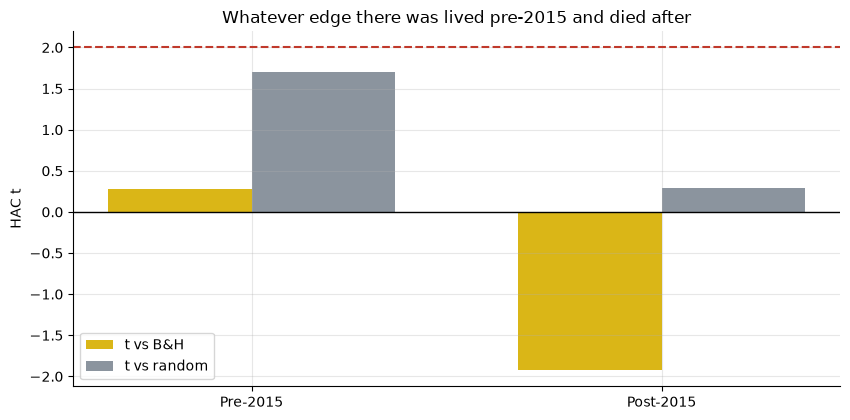

In [5]:
if HAVE_REAL:
    pre = df[df.index.year < 2015]; post = df[df.index.year >= 2015]
    rp = st.race(pre, 60, 1.0, 5.0); rq = st.race(post, 60, 1.0, 5.0)
    rows = [['Pre-2015', rp['switch']['ann_return']*100, rp['buy_hold']['ann_return']*100, rp['t_vs_bh'], rp['t_vs_random']],
            ['Post-2015', rq['switch']['ann_return']*100, rq['buy_hold']['ann_return']*100, rq['t_vs_bh'], rq['t_vs_random']]]
else:
    rows = [['Pre-2015', 10.4, 7.6, 0.28, 1.7],
            ['Post-2015', 8.0, 14.0, -1.93, 0.3]]
split = pd.DataFrame(rows, columns=['period','switch ann%','B&H ann%','t vs B&H','t vs random'])
print(split.round(2).to_string(index=False))
fig, ax = plt.subplots(figsize=(8.6, 4.3))
x = np.arange(2); w = .35
ax.bar(x-w/2, split['t vs B&H'], w, label='t vs B&H', color=AMBER)
ax.bar(x+w/2, split['t vs random'], w, label='t vs random', color=GREY)
ax.axhline(2, ls='--', c=RED); ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(split['period']); ax.legend()
ax.set_ylabel('HAC t'); ax.set_title('Whatever edge there was lived pre-2015 and died after')
plt.tight_layout(); plt.show()

> 💡 In plain words: pre-2015 the switch edged B&H on return (+10.4% vs +7.6%) by dodging the GFC, with a respectable *t* vs random (+1.70). Post-2015 it **loses** to B&H (*t* = -1.93) and the random edge collapses to +0.30. The 'signal' was one crisis. **H₃ rejected.**

## 5 · The verdict

- **Signal `WEAK`** — *t*(switch − B&H) negative in all 12 cells (H₁ rejected); *t*(switch − random) = +2.30 at one seed but +1.87 averaged over 20 (below the bar), and a pre-2015 artefact (post-2015 +0.30). Some real risk-off info, not a certifiable signal.
- **Tradability `MIRAGE`** — +8.88%/yr vs B&H +11.19%/yr, excess Sharpe 0.594 vs 0.561 (tied), and no cost level uncovers an edge because none exists over the passive default.
- **Times equities like Dr. Copper? `BUSTED`** — a defensive gauge (maxDD −29% vs −55%) that beats random timing but loses to buy-and-hold in every parameterisation. Risk-off thermometer, not equity timer.

## 6 · Could you trade it? — the cost sweep is moot

With ~14 switches/yr costs are small, but they are irrelevant: the gross switch already trails buy-and-hold, so there is nothing for costs to erode away from.

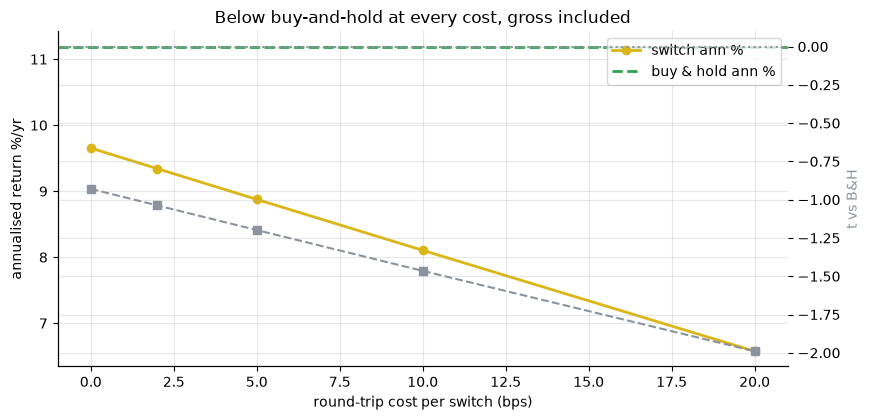

gross: switch 9.65%/yr vs B&H 11.19%/yr; t_vs_bh stays negative across costs


In [6]:
costs = [0, 2, 5, 10, 20]
if HAVE_REAL:
    anns = [st.race(df, 60, 1.0, c)['switch']['ann_return']*100 for c in costs]
    ts2 = [st.race(df, 60, 1.0, c)['t_vs_bh'] for c in costs]
    bh = st.race(df, 60, 1.0, 5.0)['buy_hold']['ann_return']*100
else:
    anns = [9.65, 9.34, 8.88, 8.1, 6.58]; ts2 = [-0.93, -1.04, -1.2, -1.46, -1.99]; bh = 11.19
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(costs, anns, 'o-', c=AMBER, lw=2, label='switch ann %')
ax.axhline(bh, ls='--', c=GREEN, lw=2, label='buy & hold ann %')
ax2 = ax.twinx(); ax2.plot(costs, ts2, 's--', c=GREY, lw=1.5, label='t vs B&H')
ax2.axhline(0, ls=':', c=GREY); ax2.set_ylabel('t vs B&H', color=GREY)
ax.set_xlabel('round-trip cost per switch (bps)'); ax.set_ylabel('annualised return %/yr')
ax.legend(loc='upper right'); ax.set_title('Below buy-and-hold at every cost, gross included')
plt.tight_layout(); plt.show()
print(f'gross: switch {anns[0]:.2f}%/yr vs B&H {bh:.2f}%/yr; t_vs_bh stays negative across costs')

> 💡 In plain words: even gross the switch earns +9.65%/yr vs the index's +11.19%, with *t* vs B&H = -0.93. This is the signature of a **Mirage**: not an edge eaten by costs, but no edge at all over the thing you'd do for free.

## 7 · Going further — the synthetic positive control

Is the *engine* a faithful detector, or does it always print a loss? Plant a forward ratio→equity link (`pred_r < 0`: a high ratio precedes lower returns — the folklore-consistent control) and confirm the switch banks it.

 pred_r  switch Sharpe  B&H Sharpe  t vs B&H
  0.000         -0.163      -0.064    -0.586
 -0.005          4.759       1.103    11.346
 -0.010          7.457       1.642    12.222


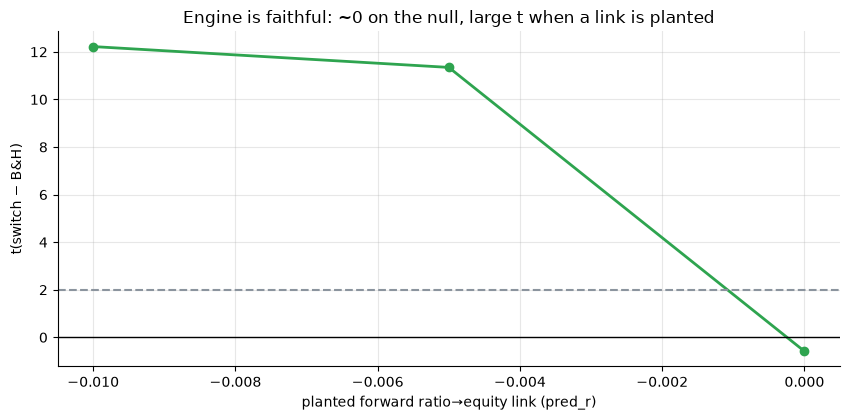

In [7]:
prs = [0.0, -0.005, -0.01]
rows = []
for pr in prs:
    d, _ = data.synthetic_daily(n_days=4000, pred_r=pr, seed=305)
    rr = st.race(d, 60, 1.0, 5.0)
    rows.append((pr, rr['switch']['sharpe_excess'], rr['buy_hold']['sharpe_excess'], rr['t_vs_bh']))
ctrl = pd.DataFrame(rows, columns=['pred_r','switch Sharpe','B&H Sharpe','t vs B&H'])
print(ctrl.round(3).to_string(index=False))
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.plot(ctrl['pred_r'], ctrl['t vs B&H'], 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted forward ratio→equity link (pred_r)'); ax.set_ylabel('t(switch − B&H)')
ax.set_title('Engine is faithful: ~0 on the null, large t when a link is planted')
plt.tight_layout(); plt.show()

On the null (`pred_r=0`) the switch is indistinguishable from B&H (*t* = -0.59); plant even a small folklore-consistent link and the engine banks it cleanly (*t* = +11.3 at pred_r=−0.005). So the engine is a faithful detector, and the real-tape 'no' is a statement about **the market**: the gold/oil ratio is a real risk-off thermometer but not a tradable equity timer.

For the copper original as a forecasting regression, see [Study 85 — Dr-Copper](../../85-dr-copper/); for the metals-ratio mean-reversion trade, [Study 113 — Gold-Silver-Ratio](../../113-gold-silver-ratio/).